In [1]:

import os
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
#=======preprocessing=====
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

#======Model and Feature========
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
#==========Training and evaluation===========
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix, classification_report
import joblib

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\ProgramData\anaconda3\Lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\ProgramData\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
def load_imdb_data(base_path):
    data =[]

    for split in ['train','test']:
        for sentiment in ['pos','neg']:
            folder_path = os.path.join(base_path,split,sentiment)
            for filename in os.listdir(folder_path):
                if filename.endswith('.txt'):
                    file_path = os.path.join(folder_path,filename)
                    with open (file_path, encoding='utf-8') as f:
                        review_text = f.read()
                    data.append({
                        'review': review_text,
                        'sentiment': sentiment,
                        'split': split
                    })
    return pd.DataFrame(data)
Data_path = r"C:\Users\Asus\OneDrive - K L University\Desktop\Sentiment_Analysis\aclImdb"
df = load_imdb_data(Data_path)
print("Dataset loaded successfully")
print(f"Shape:{df.shape} ")

Dataset loaded successfully
Shape:(50000, 3) 


sentiment
pos    25000
neg    25000
Name: count, dtype: int64


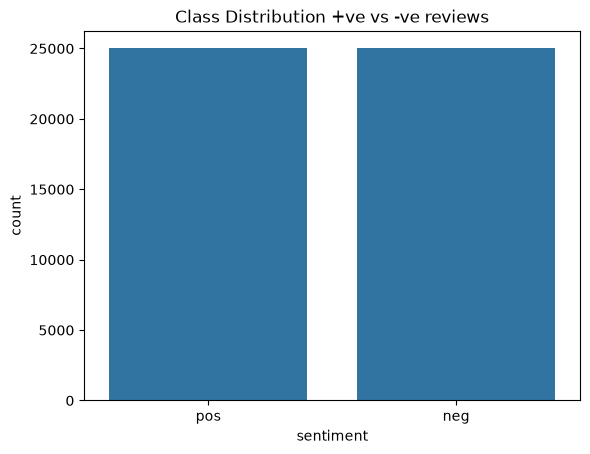

In [4]:
print(df['sentiment'].value_counts())
sns.countplot(data=df,x='sentiment')
plt.title("Class Distribution +ve vs -ve reviews")
plt.show()

In [5]:
print("Positive Review Example:\n",df[df['sentiment']=='pos']['review'].iloc[18])
print("Negative Review Example:\n",df[df['sentiment']=='neg']['review'].iloc[6])

Positive Review Example:
 If there is one thing to recommend about this film is that it is intriguing. The premise certainly draws the audience in because it is a mystery, and throughout the film there are hints that there is something dark lurking about. However, there is not much tension, and Williams' mild mannered portrayal doesn't do much to makes us relate to his obsession with the boy.<br /><br />Collete fares much better as the woman whose true nature and intentions are not very clear. The production felt rushed and holes are apparent. It certainly feels like a preview for a much more complete and better effort. The book is probably better.<br /><br />One thing is certain: Taupin must have written something truly good to have inspired at least one commendable effort.
Negative Review Example:
 The second attempt by a New York intellectual in less than 10 years to make a "Swedish" film - the first being Susan Sontag's "Brother Carl" (which was made in Sweden, with Swedish actors,

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length, dtype: float64


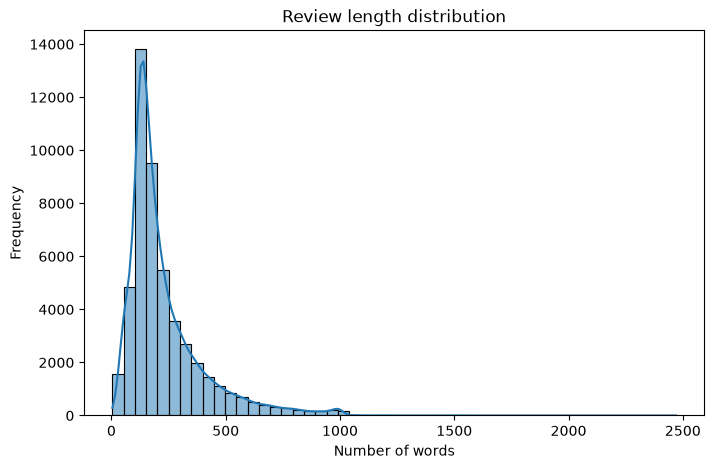

In [6]:
df['review_length'] = df['review'].apply(lambda x: len(x.split()))
print(df['review_length'].describe())
plt.figure(figsize=(8,5))
sns.histplot(df['review_length'], bins = 50, kde=True)
plt.title('Review length distribution')
plt.xlabel("Number of words")
plt.ylabel('Frequency')
plt.show()

In [7]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text,use_stemming= False):

    text = text.lower()
    text = re.sub(r'<.*?>',' ',text )
    text = re.sub(r'http\S+|www\S+',' ', text)
    text = re.sub(r'[^a-z\s]',' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t)>2]

    if use_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    else:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

In [8]:
sample_raw = df['review'].iloc[0]
sample_cleaned = clean_text(sample_raw)

print("Raw:\n",sample_raw[:500])
print("\n Clean:\n",sample_cleaned[:500])

Raw:
 Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a s

 Clean:
 bromwell high cartoon comedy ran time program school life teacher year teaching profession lead believe bromwell high satire much closer reality teacher scramble survive financially insightful student see right pathetic teacher pomp pettiness whole situation remind school knew student saw episode student repeatedly tried burn school immediately recalled high classic line inspector sack one teacher student welcome bromwell high expect many adult age think bromwell high far fetche

In [9]:
print("Cleaning will take a moment of your time. So, Please sit back and relax until then")
df['cleaned_review'] = df['review'].apply(clean_text)
print("\n Sample cleaned review:\n", df['cleaned_review'].iloc[1][:300])

Cleaning will take a moment of your time. So, Please sit back and relax until then

 Sample cleaned review:
 homelessness houselessness george carlin stated issue year never plan help street considered human everything going school work vote matter people think homeless lost cause worrying thing racism war iraq pressuring kid succeed technology election inflation worrying next end street given bet live str


In [10]:
print(df['cleaned_review'].isnull().sum())
print((df['cleaned_review']=='').sum())
df['cleaned_length'] = df['cleaned_review'].apply(lambda x:len(x.split()))
print("\n Original review length stats:")
print(df['review_length'].describe())
print("\n Cleaned review length stats:")
print(df['cleaned_length'].describe())


0
0

 Original review length stats:
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length, dtype: float64

 Cleaned review length stats:
count    50000.000000
mean       116.542160
std         88.265018
min          3.000000
25%         62.000000
50%         86.000000
75%        142.000000
max       1390.000000
Name: cleaned_length, dtype: float64


In [11]:
#=========Converting labels  to binary numbers==============
df['label'] = df['sentiment'].map({'pos':1,'neg':0})
print("Label Distribution:")
print(df['label'].value_counts())
print("\n Sample Rows:")
print(df[['sentiment','label']].head(10))


Label Distribution:
label
1    25000
0    25000
Name: count, dtype: int64

 Sample Rows:
  sentiment  label
0       pos      1
1       pos      1
2       pos      1
3       pos      1
4       pos      1
5       pos      1
6       pos      1
7       pos      1
8       pos      1
9       pos      1


In [12]:
#=============Splitting data into Training and test sets==========
X = df['cleaned_review']
y = df['label']

X_train, X_test, y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state= 42, stratify = y)

print(f"Training Samples: {len(X_train)}")
print(f"Test Samples: {len(X_test)}")
print(f"\n Training label distribution:\n{y_train.value_counts()}")
print(f"\n Test label distribution:\n{y_test.value_counts()}")

Training Samples: 40000
Test Samples: 10000

 Training label distribution:
label
1    20000
0    20000
Name: count, dtype: int64

 Test label distribution:
label
0    5000
1    5000
Name: count, dtype: int64


In [13]:
tfidf = TfidfVectorizer(
    max_features= 50000,
    ngram_range = (1,2),
    min_df= 3,
    max_df = 0.90,
    sublinear_tf = True
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF matrix shape(train):",X_train_tfidf.shape)
print("TF-IDF matrix shape(test):",X_test_tfidf.shape)
print("\n Matrix is sparse - non-zero elements:",X_train_tfidf.nnz)
print("Sparsity: {:.2f}%".format(
    100* (1 - X_train_tfidf.nnz/ (X_train_tfidf.shape[0] * X_train_tfidf.shape[1] ) )
))


TF-IDF matrix shape(train): (40000, 50000)
TF-IDF matrix shape(test): (10000, 50000)

 Matrix is sparse - non-zero elements: 4718115
Sparsity: 99.76%


In [14]:
# ===========Inspect the vocabulary==============

feature_names = tfidf.get_feature_names_out()
print(f"Total features (vocabulary size): {len(feature_names)}")
print("\nFirst 20 features (alphabetical):", feature_names[:20])
print("\nSome bigram examples:")
bigrams= [f for f in feature_names if ' ' in f]
print(bigrams[:20])

sample_vector = X_train_tfidf[0].toarray()[0]
top_indices= sample_vector.argsort()[-15:][::-1]
print("\nTop 15 TF-IDF features for first training review:")
for idx in top_indices:
    print(f" '{feature_names[idx]}' -> score: {sample_vector[idx]:.4f} ")

Total features (vocabulary size): 50000

First 20 features (alphabetical): ['aaa' 'aag' 'aaliyah' 'aamir' 'aamir khan' 'aardman' 'aaron'
 'aaron carter' 'aaron eckhart' 'aback' 'abandon' 'abandoned' 'abandoning'
 'abandonment' 'abba' 'abbey' 'abbie' 'abbot' 'abbott' 'abbott costello']

Some bigram examples:
['aamir khan', 'aaron carter', 'aaron eckhart', 'abbott costello', 'abc family', 'ability make', 'able appreciate', 'able bring', 'able capture', 'able create', 'able enjoy', 'able find', 'able get', 'able give', 'able keep', 'able look', 'able make', 'able play', 'able predict', 'able pull']

Top 15 TF-IDF features for first training review:
 'kuzco' -> score: 0.3807 
 'complaining' -> score: 0.1989 
 'style much' -> score: 0.1538 
 'animation character' -> score: 0.1538 
 'amazing look' -> score: 0.1538 
 'old joke' -> score: 0.1526 
 'kitt' -> score: 0.1526 
 'new school' -> score: 0.1515 
 'show worth' -> score: 0.1515 
 'actually love' -> score: 0.1515 
 'look make' -> score: 0

In [15]:
#================Baseline SVM with linear Kernel=============

svm_linear = SVC(
    kernel = 'linear',
    C=1.0,
    random_state = 42,
    verbose = True
)
print("Training Linear SVM")
print("Training makes a model optimal so wait for few minutes it's completely normal....")

import time
start = time.time()
svm_linear.fit(X_train_tfidf,y_train)
end = time.time()

print(f"\n You waited for {end - start:.1f} seconds")
print(f"Number of support vectors: {svm_linear.n_support_} ")
print(f"Total Support Vectors : {sum(svm_linear.n_support_)}")

Training Linear SVM
Training makes a model optimal so wait for few minutes it's completely normal....
[LibSVM]
 You waited for 1962.7 seconds
Number of support vectors: [7973 8381] 
Total Support Vectors : 16354


In [16]:
y_pred_linear = svm_linear.predict(X_test_tfidf)

acc= accuracy_score(y_test,y_pred_linear)
prec = precision_score(y_test,y_pred_linear)
rec = recall_score(y_test,y_pred_linear)
f1 = f1_score(y_test,y_pred_linear)

print("Linear SVM - Evaluation results")
print(f"\n Accuracy: {acc:.4f} ({acc*100:.2f}%) ")
print(f" Precision : {prec:.4f} ")
print(f" Recall : {rec:.4f} ")
print(f" F1-Score : {f1:.4f} ")
print("\nFull Classification Report : ")
print(classification_report(y_test,y_pred_linear, target_names=['Negative','Positive']))

Linear SVM - Evaluation results

 Accuracy: 0.9055 (90.55%) 
 Precision : 0.8998 
 Recall : 0.9126 
 F1-Score : 0.9062 

Full Classification Report : 
              precision    recall  f1-score   support

    Negative       0.91      0.90      0.90      5000
    Positive       0.90      0.91      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000




True Negatives  (correctly predicted negative): 4492
False Positives (predicted positive, was negative): 508
False Negatives (predicted negative, was positive): 437
True Positives  (correctly predicted positive): 4563


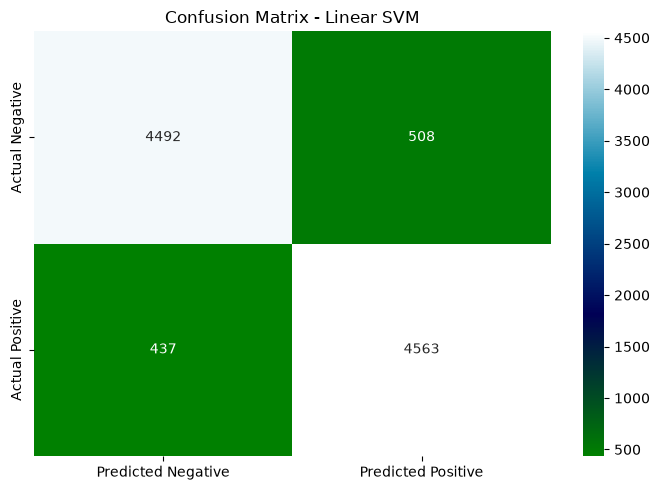

In [17]:
cm = confusion_matrix(y_test, y_pred_linear)
plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='ocean',
    xticklabels = ['Predicted Negative', 'Predicted Positive'],
    yticklabels = ['Actual Negative', 'Actual Positive']
)

plt.title("Confusion Matrix - Linear SVM")
plt.tight_layout()
plt.show

tn,fp,fn,tp = cm.ravel()

print(f"\nTrue Negatives  (correctly predicted negative): {tn}")
print(f"False Positives (predicted positive, was negative): {fp}")
print(f"False Negatives (predicted negative, was positive): {fn}")
print(f"True Positives  (correctly predicted positive): {tp}")

In [18]:
import time

results = {}
#==============Kernel configs to loop over=======================

kernels = [
    {
    'name' : 'Linear',
    'kernel' : 'linear',
    'params' : {'C':10}
    },
    {
    'name' : 'Polynomial',
    'kernel' : 'poly',
    'params' : {'C': 1.0, 'degree' : 3, 'coef0': 1}
    },
    {
    'name' : 'RBF',
    'kernel' : 'rbf',
    'params' : {'C': 1.0,'gamma':'scale'}
    },
]

for config in kernels:
    print(f"Training {config['name']} kernel SVM... ")
    model = SVC(
        kernel = config['kernel'],
        random_state=42,
        **config['params']
    )
    t0 = time.time()
    model.fit(X_train_tfidf,y_train)
    train_time = time.time() - t0

    t1 = time.time()
    y_pred = model.predict(X_test_tfidf)
    pred_time= time.time() -t1

    results[config['name']] = {
        'model' : model,
        'predictions' : y_pred,
        'accuracy' : accuracy_score(y_test,y_pred),
        'precision' : precision_score(y_test,y_pred),
        'recall' : recall_score(y_test,y_pred),
        'f1' : f1_score(y_test,y_pred),
        'train_time' : train_time,
        'pred_time' : pred_time,
        'n_sv' : sum(model.n_support_)
    }
    print(f" Done in {train_time:.1f}s  |"
         f"Accuracy: {results[config['name']]['accuracy']:.4f} | "
          f" F1: {results[config['name']]['f1']:.4f}  | "  
            f"SVs: {results[config['name']]['n_sv']}")

Training Linear kernel SVM... 
 Done in 5055.3s  |Accuracy: 0.8870 |  F1: 0.8874  | SVs: 14926
Training Polynomial kernel SVM... 
 Done in 3489.6s  |Accuracy: 0.9086 |  F1: 0.9093  | SVs: 23979
Training RBF kernel SVM... 
 Done in 3368.4s  |Accuracy: 0.9071 |  F1: 0.9083  | SVs: 25071


In [19]:
print(f"\n{'Kernel':<14} {'Accuracy':>18} {'Precision':>10} "
     f"{'Recall':>10} {'F1':>8} {'Train(s)':>14} {'SVs':>8}")
print("-"*90)
for name, r in results.items():
    print(f"{name:<14} {r['accuracy']:>16.4f} {r['precision']:>10.4f}  "
         f"{r['recall']:>11.4f} {r['f1']:>12.4f}  "
         f"{r['train_time']:>10.4f} {r['n_sv']:>8}  ")


Kernel                   Accuracy  Precision     Recall       F1       Train(s)      SVs
------------------------------------------------------------------------------------------
Linear                   0.8870     0.8842       0.8906       0.8874   5055.3218    14926  
Polynomial               0.9086     0.9022       0.9166       0.9093   3489.6211    23979  
RBF                      0.9071     0.8967       0.9202       0.9083   3368.3816    25071  


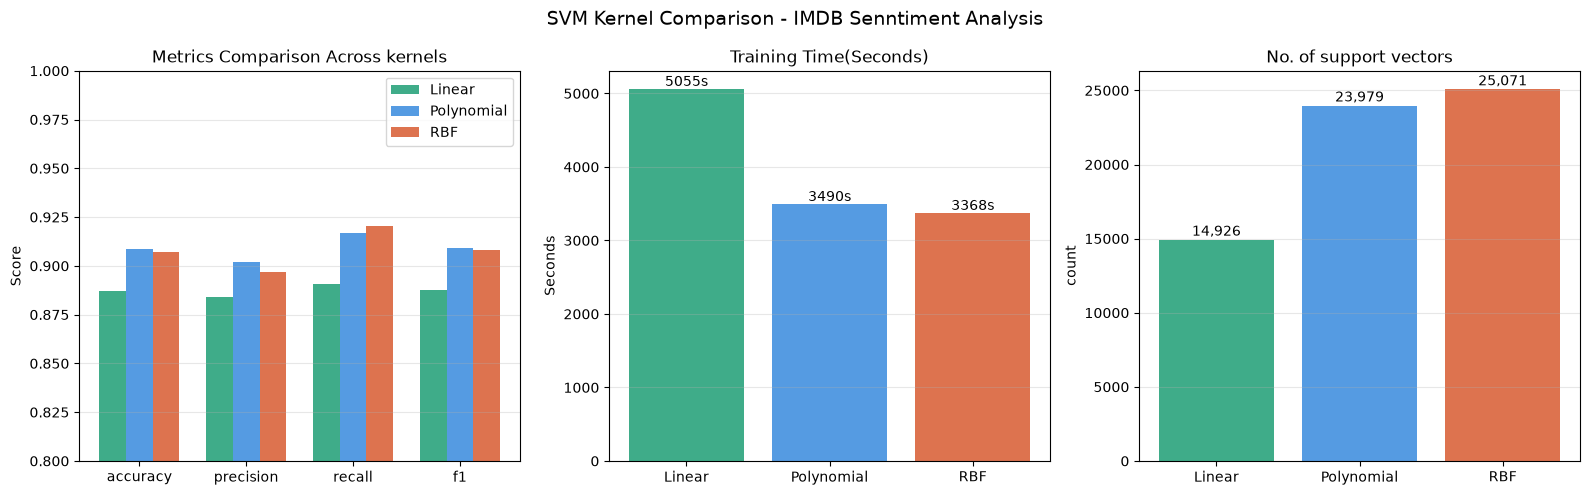

In [20]:
fig,axes =plt.subplots(1,3,figsize=(16,5))

metrics = ['accuracy' , 'precision','recall', 'f1']
bar_colors = ['#1D9E75', '#378ADD', '#D85A30']
names = list(results.keys())
x = np.arange(len(metrics))
width = 0.25
for i,(name,color) in enumerate(zip(names, bar_colors)):
    vals = [results[name][m] for m in metrics]
    axes[0].bar(x+i*width,vals,width,label=name,color=color,alpha=0.85)
axes[0].set_title('Metrics Comparison Across kernels')
axes[0].set_xticks(x+width)
axes[0].set_xticklabels(['accuracy','precision','recall','f1'])
axes[0].set_ylim(0.80,1.00)
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(axis='y',alpha=0.3)
#---------------------------------------------------------------------------------------------

train_times = [results[n]['train_time'] for n in names]
bars = axes[1].bar(names,train_times,color=bar_colors,alpha = 0.85)
axes[1].set_title('Training Time(Seconds)')
axes[1].set_ylabel('Seconds')
axes[1].grid(axis = 'y',alpha= 0.3)
for bar,val in zip(bars,train_times):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() +1,
                f'{val:.0f}s',
                ha = 'center' ,va = 'bottom',fontsize = 10)
#==========================================================================

n_svs = [results[n]['n_sv'] for n in names]
bars2 = axes[2].bar(names,n_svs,color=bar_colors,alpha=0.85)
axes[2].set_title("No. of support vectors")
axes[2].set_ylabel('count')
axes[2].grid(axis ='y',alpha= 0.3)
for bar, val in zip(bars2,n_svs):
    axes[2].text(bar.get_x()+ bar.get_width()/2,
                bar.get_height()+50,
                f'{val:,}',
                ha='center',va='bottom',fontsize=10)
plt.suptitle('SVM Kernel Comparison - IMDB Senntiment Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('kernel_comparison.png', dpi=150,bbox_inches='tight')
plt.show()

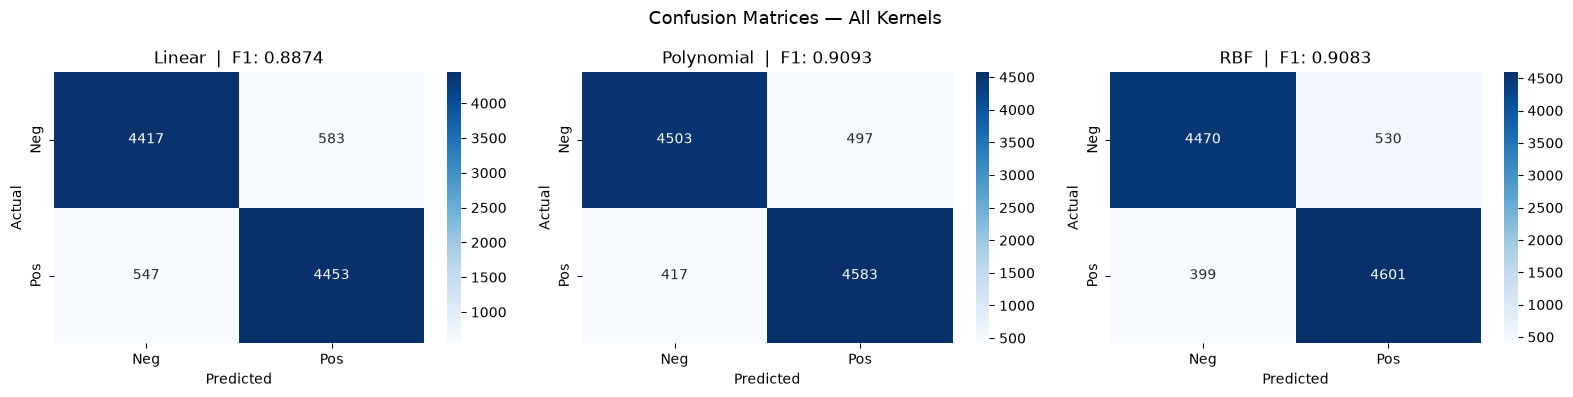

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['predictions'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Neg', 'Pos'],
        yticklabels=['Neg', 'Pos']
    )
    ax.set_title(f'{name}  |  F1: {r["f1"]:.4f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Kernels', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:

print("Setting up GridSearchCV...")
print("This will try 6 values of C × 5 folds = 30 training runs")
print("Estimated time: 15-30 minutes\n")

param_grid = {
    'estimator__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

base_model = LinearSVC(
    max_iter=2000,
    random_state=42
)

calibrated = CalibratedClassifierCV(base_model)

grid_search = GridSearchCV(
    estimator=calibrated,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    refit=True
)

t0 = time.time()
grid_search.fit(X_train_tfidf, y_train)
print(f"\nGrid search complete in {time.time()-t0:.1f}s")
print(f"Best C value : {grid_search.best_params_}")
print(f"Best CV F1   : {grid_search.best_score_:.4f}")

Setting up GridSearchCV...
This will try 6 values of C × 5 folds = 30 training runs
Estimated time: 15-30 minutes

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Grid search complete in 109.8s
Best C value : {'estimator__C': 1.0}
Best CV F1   : 0.9047


In [43]:
cv_results = pd.DataFrame(grid_search.cv_results_)

summary = cv_results[[
    'param_estimator__C',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].sort_values('rank_test_score')

summary.columns = ['C value', 'Mean F1', 'Std F1', 'Rank']
print(summary.to_string(index=False))

 C value  Mean F1   Std F1  Rank
   1.000 0.904740 0.001868     1
   0.100 0.899232 0.003606     2
  10.000 0.897914 0.003073     3
 100.000 0.896033 0.003119     4
   0.010 0.873600 0.003317     5
   0.001 0.855110 0.002662     6


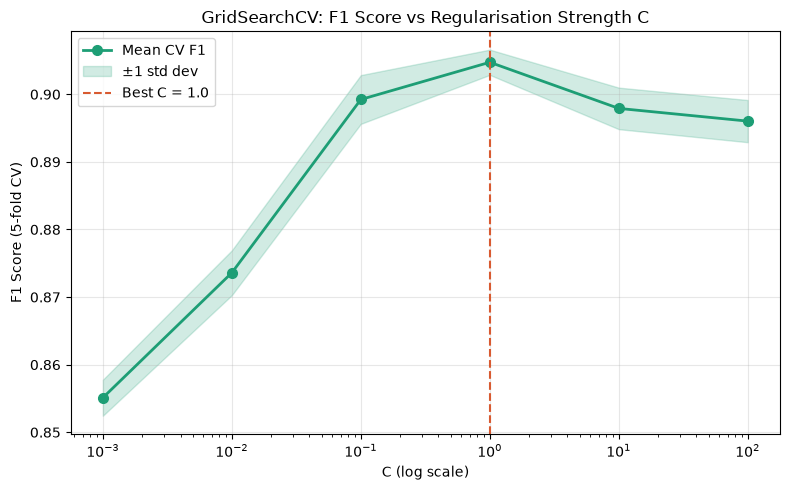

In [45]:
c_values   = cv_results['param_estimator__C'].astype(float)
mean_scores = cv_results['mean_test_score']
std_scores  = cv_results['std_test_score']

plt.figure(figsize=(8, 5))
plt.semilogx(c_values, mean_scores, 'o-', color='#1D9E75',
             linewidth=2, markersize=7, label='Mean CV F1')
plt.fill_between(
    c_values,
    mean_scores - std_scores,
    mean_scores + std_scores,
    alpha=0.2, color='#1D9E75', label='±1 std dev'
)
plt.axvline(
    x=grid_search.best_params_['estimator__C'],
    color='#D85A30', linestyle='--', linewidth=1.5,
    label=f"Best C = {grid_search.best_params_['estimator__C']}"
)
plt.xlabel('C (log scale)')
plt.ylabel('F1 Score (5-fold CV)')
plt.title('GridSearchCV: F1 Score vs Regularisation Strength C')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gridsearch_C.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test_tfidf)

acc  = accuracy_score(y_test, y_pred_tuned)
prec = precision_score(y_test, y_pred_tuned)
rec  = recall_score(y_test, y_pred_tuned)
f1   = f1_score(y_test, y_pred_tuned)

print("=" * 50)
print("   TUNED LINEAR SVM — FINAL TEST RESULTS")
print("=" * 50)
print(f"  Best C        : {grid_search.best_params_['estimator__C']}")
print(f"  Accuracy      : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision     : {prec:.4f}")
print(f"  Recall        : {rec:.4f}")
print(f"  F1-Score      : {f1:.4f}")
print("=" * 50)

baseline_f1 = results['Linear']['f1']
print(f"\n  Baseline Linear F1 (C=1.0) : {baseline_f1:.4f}")
print(f"  Tuned Linear F1            : {f1:.4f}")
print(f"  Improvement                : +{(f1 - baseline_f1):.4f}")

joblib.dump(best_model,  'svm_best_model.pkl')
joblib.dump(tfidf,       'tfidf_vectorizer.pkl')
print("\nModel saved: svm_best_model.pkl")
print("Vectorizer saved: tfidf_vectorizer.pkl")

   TUNED LINEAR SVM — FINAL TEST RESULTS
  Best C        : 1.0
  Accuracy      : 0.9059  (90.59%)
  Precision     : 0.9028
  Recall        : 0.9098
  F1-Score      : 0.9063

  Baseline Linear F1 (C=1.0) : 0.8874
  Tuned Linear F1            : 0.9063
  Improvement                : +0.0189

Model saved: svm_best_model.pkl
Vectorizer saved: tfidf_vectorizer.pkl


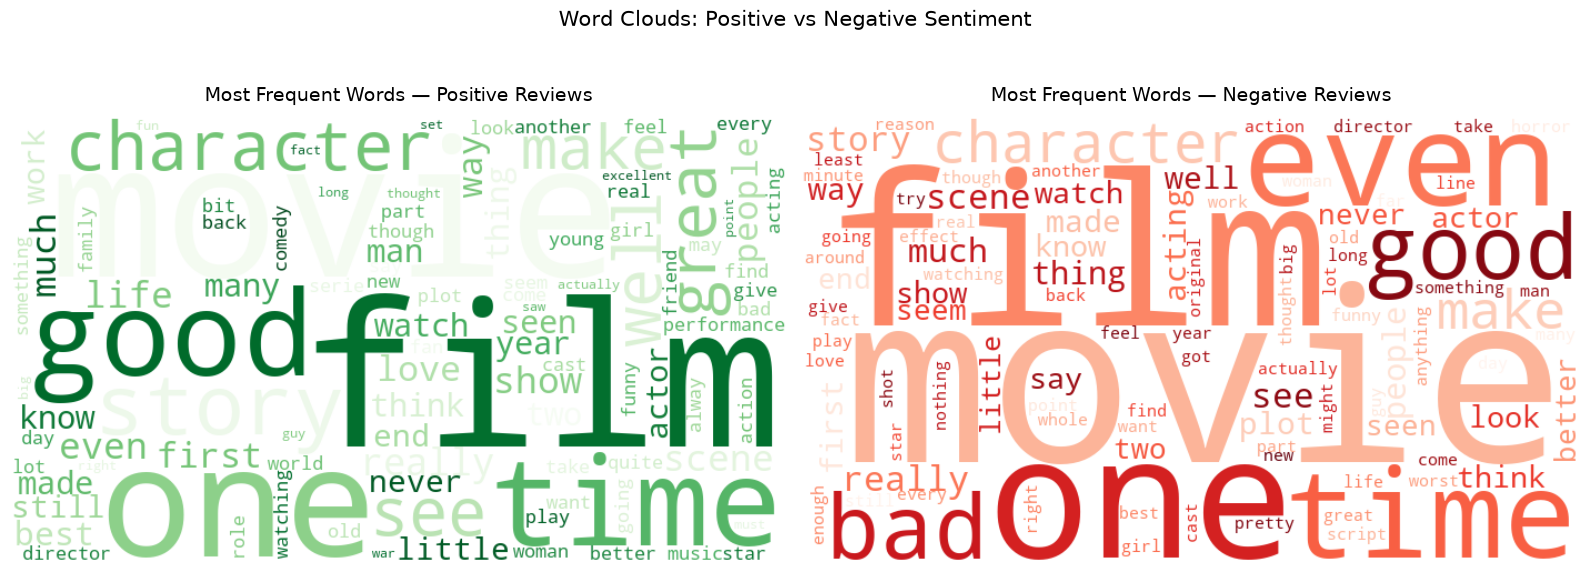

Saved: wordclouds.png


In [54]:

from wordcloud import WordCloud

positive_text = ' '.join(df[df['sentiment'] == 'pos']['cleaned_review'].tolist())

negative_text = ' '.join(df[df['sentiment'] == 'neg']['cleaned_review'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_pos = WordCloud(
    width=700,
    height=400,
    background_color='white',
    colormap='Greens',
    max_words=100,
    collocations=False
).generate(positive_text)

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Frequent Words — Positive Reviews',
                   fontsize=14, pad=12)

wc_neg = WordCloud(
    width=700,
    height=400,
    background_color='white',
    colormap='Reds',
    max_words=100,
    collocations=False
).generate(negative_text)

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Frequent Words — Negative Reviews',
                   fontsize=14, pad=12)

plt.suptitle('Word Clouds: Positive vs Negative Sentiment',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: wordclouds.png")

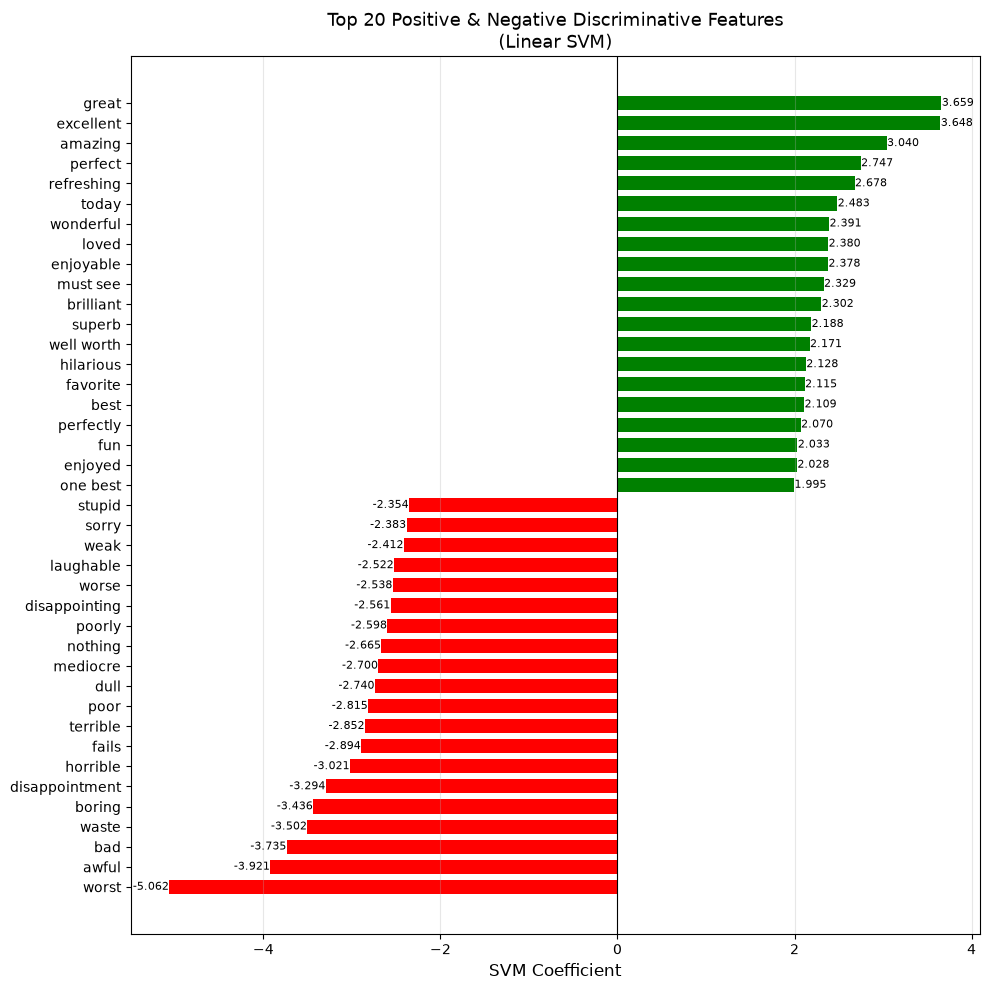

Saved: top_features.png


In [64]:
inner_svc = best_model.calibrated_classifiers_[0].estimator

coefficients  = inner_svc.coef_[0]
feature_names = tfidf.get_feature_names_out()

coef_df = pd.DataFrame({
    'feature'    : feature_names,
    'coefficient': coefficients
})

top_pos = coef_df.nlargest(20, 'coefficient')
top_neg = coef_df.nsmallest(20, 'coefficient')

top_features = pd.concat([top_neg, top_pos]).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#FF0000' if c < 0 else '#008000'
          for c in top_features['coefficient']]

bars = ax.barh(
    top_features['feature'],
    top_features['coefficient'],
    color=colors,
    edgecolor='none',
    height=0.7
)

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlabel('SVM Coefficient', fontsize=12)
ax.set_title('Top 20 Positive & Negative Discriminative Features\n'
             '(Linear SVM)', fontsize=13)
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, top_features['coefficient']):
    ax.text(
        val + (0.005 if val >= 0 else -0.005),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=8
    )

plt.tight_layout()
plt.savefig('top_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: top_features.png")

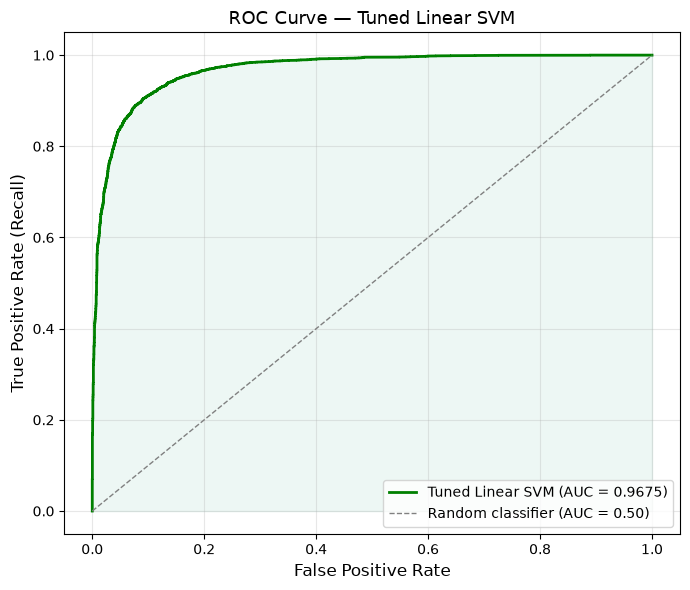

AUC Score: 0.9675
Saved: roc_curve.png


In [70]:
from sklearn.metrics import roc_curve, auc

y_prob = best_model.predict_proba(X_test_tfidf)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr,
         color='#008000',
         linewidth=2,
         label=f'Tuned Linear SVM (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1],
         color='gray',
         linewidth=1,
         linestyle='--',
         label='Random classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.08, color='#1D9E75')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve — Tuned Linear SVM', fontsize=13)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"AUC Score: {roc_auc:.4f}")
print("Saved: roc_curve.png")

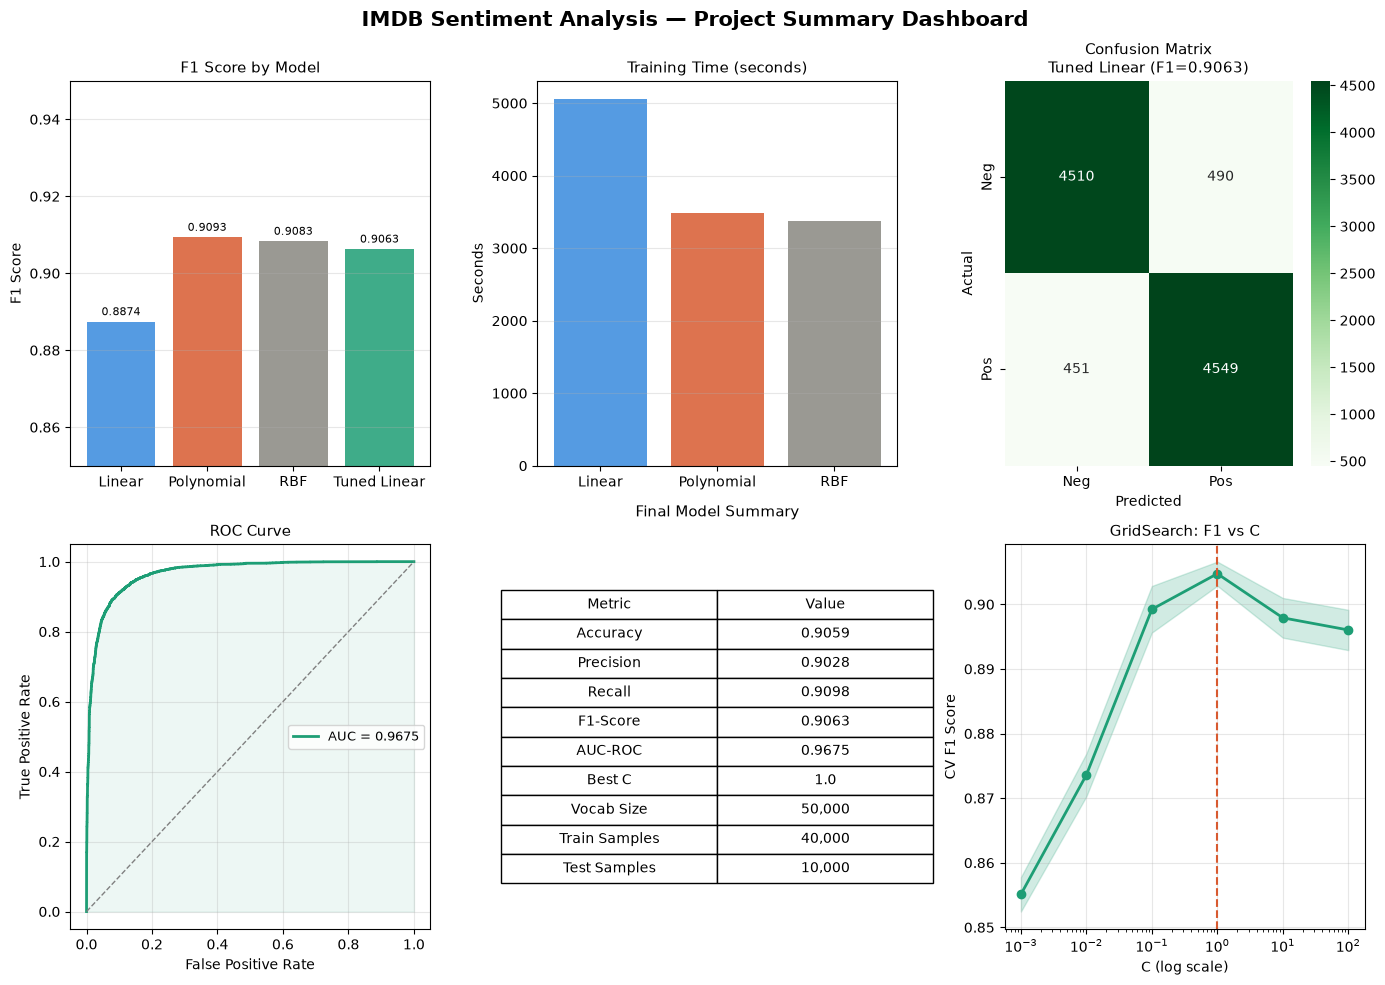

Saved: summary_dashboard.png


In [72]:
fig = plt.figure(figsize=(14, 10))
fig.suptitle('IMDB Sentiment Analysis — Project Summary Dashboard',
             fontsize=15, fontweight='bold', y=0.98)

# ── Panel 1: Kernel F1 comparison ─────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
kernel_names = list(results.keys()) + ['Tuned Linear']
kernel_f1s   = [results[k]['f1'] for k in results.keys()] + [f1]
colors_bar   = ['#378ADD', '#D85A30', '#888780', '#1D9E75']
bars = ax1.bar(kernel_names, kernel_f1s, color=colors_bar, alpha=0.85)
ax1.set_ylim(0.85, 0.95)
ax1.set_title('F1 Score by Model', fontsize=11)
ax1.set_ylabel('F1 Score')
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, kernel_f1s):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8)

# ── Panel 2: Training time ─────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
t_names = list(results.keys())
t_times = [results[k]['train_time'] for k in t_names]
ax2.bar(t_names, t_times, color=['#378ADD','#D85A30','#888780'], alpha=0.85)
ax2.set_title('Training Time (seconds)', fontsize=11)
ax2.set_ylabel('Seconds')
ax2.grid(axis='y', alpha=0.3)

# ── Panel 3: Confusion matrix (best model) ────────────────────
ax3 = fig.add_subplot(2, 3, 3)
cm_best = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            ax=ax3,
            xticklabels=['Neg', 'Pos'],
            yticklabels=['Neg', 'Pos'])
ax3.set_title(f'Confusion Matrix\nTuned Linear (F1={f1:.4f})', fontsize=11)
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

# ── Panel 4: ROC curve ────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
ax4.plot(fpr, tpr, color='#1D9E75', linewidth=2,
         label=f'AUC = {roc_auc:.4f}')
ax4.plot([0,1],[0,1],'--', color='gray', linewidth=1)
ax4.fill_between(fpr, tpr, alpha=0.08, color='#1D9E75')
ax4.set_title('ROC Curve', fontsize=11)
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

# ── Panel 5: Metrics summary table ───────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
ax5.axis('off')
table_data = [
    ['Metric',      'Value'],
    ['Accuracy',    f'{acc:.4f}'],
    ['Precision',   f'{prec:.4f}'],
    ['Recall',      f'{rec:.4f}'],
    ['F1-Score',    f'{f1:.4f}'],
    ['AUC-ROC',     f'{roc_auc:.4f}'],
    ['Best C',      f"{grid_search.best_params_['estimator__C']}"],
    ['Vocab Size',  '50,000'],
    ['Train Samples','40,000'],
    ['Test Samples', '10,000'],
]
table = ax5.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)
ax5.set_title('Final Model Summary', fontsize=11, pad=20)

# ── Panel 6: C value search curve ────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
ax6.semilogx(c_values, mean_scores, 'o-',
             color='#1D9E75', linewidth=2, markersize=6)
ax6.fill_between(c_values,
                 mean_scores - std_scores,
                 mean_scores + std_scores,
                 alpha=0.2, color='#1D9E75')
ax6.axvline(x=grid_search.best_params_['estimator__C'],
            color='#D85A30', linestyle='--', linewidth=1.5)
ax6.set_xlabel('C (log scale)')
ax6.set_ylabel('CV F1 Score')
ax6.set_title('GridSearch: F1 vs C', fontsize=11)
ax6.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: summary_dashboard.png")